# 05 — Results: collation across all schemes — CIC-IDS-2017 — SVM-RFE study

Reads every `runs/<scheme>/<model>/metrics.json` plus the CV tables and produces the
comparison tables and plots. **Every number here comes from a saved artifact file.**
The final section also compares this study's selected features against the base
(RF-importance) study's top 40, when that study's artifacts are present.

In [1]:
DATASET = "cic2017"
FT_ROOT = "ft40_rfe"

In [2]:
import sys
from pathlib import Path

def _find_nb_common():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for c in (cand, cand / "notebooks"):
            if (c / "nb_common.py").exists():
                return c
    raise FileNotFoundError("nb_common.py not found relative to " + str(Path.cwd()))
sys.path.insert(0, str(_find_nb_common()))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nb_common as nbc
from ids import config
from ids.evaluation.cross_val import METRIC_NAMES

P = nbc.ft_paths(DATASET, FT_ROOT)
log = nbc.setup_logging(P.logs / "05_results.log", "nb05")

rows = []
for mp in sorted(P.runs.glob("*/*/metrics.json")):
    d = nbc.load_json(mp)
    for split in ("test", "validation"):
        if split in d:
            m = {k: v for k, v in d[split].items() if k != "name"}
            rows.append({"scheme": d["scheme"], "model": d["model"], "split": split,
                         "n_train": d["n_train"], "fit_seconds": d["fit_seconds"], **m})
summary = pd.DataFrame(rows)
summary.to_csv(P.results / "summary_all_schemes.csv", index=False)
log.info("collected %d (scheme, model, split) results", len(summary))
summary.head(10)

2026-07-06 17:18:21,886 INFO nb05: collected 25 (scheme, model, split) results


,scheme,model,split,n_train,fit_seconds,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,detection_time_ms,n_test
0,70_20_10,decision_tree,test,1764558,13.306,0.996315,0.764504,0.916973,0.813214,0.998116,0.000270,252080
1,70_20_10,decision_tree,validation,1764558,13.306,0.996188,0.730382,0.909769,0.789525,0.998111,0.000258,504160
2,70_20_10,knn,test,1764558,2.086,0.989027,0.677463,0.918569,0.728846,0.997927,0.461040,252080
3,70_20_10,knn,validation,1764558,2.086,0.988821,0.673604,0.896348,0.721769,0.997813,0.453001,504160
4,70_20_10,naive_bayes,test,1764558,2.066,0.720938,0.338664,0.722467,0.372923,0.966017,0.001097,252080
5,70_20_10,naive_bayes,validation,1764558,2.066,0.720739,0.403582,0.755299,0.437036,0.965806,0.000666,504160
6,70_20_10,random_forest,test,1764558,30.788,0.995720,0.835030,0.912919,0.854384,0.999818,0.003549,252080
7,70_20_10,random_forest,validation,1764558,30.788,0.995402,0.855001,0.899879,0.850662,0.999784,0.003489,504160
8,70_20_10,svm,test,1764558,5.527,0.776023,0.304787,0.870275,0.366918,0.973879,0.000403,252080
9,70_20_10,svm,validation,1764558,5.527,0.775444,0.304145,0.847418,0.366378,0.973545,0.000393,504160


## 1. Test-set comparison: model × scheme, one table per metric

In [3]:
test = summary[summary["split"] == "test"]
pivots = {}
for metric in METRIC_NAMES + ["detection_time_ms", "fit_seconds"]:
    pv = test.pivot_table(index="model", columns="scheme", values=metric).round(4)
    pv.to_csv(P.results / f"pivot_{metric}.csv")
    pivots[metric] = pv
log.info("saved %d pivot tables to %s", len(pivots), P.results)
pivots["f1_macro"]

2026-07-06 17:18:21,944 INFO nb05: saved 7 pivot tables to /Users/MAC/Projects/IDS/backend/artifacts/ft40_rfe/cic2017/results


scheme,70_20_10,70_30,80_20,90_10
model,,,,
decision_tree,0.8132,0.7978,0.7959,0.8330
knn,0.7288,0.7064,0.7125,0.7247
naive_bayes,0.3729,0.4211,0.4117,0.3680
random_forest,0.8544,0.8386,0.8594,0.8569
svm,0.3669,0.3668,0.3635,0.3696


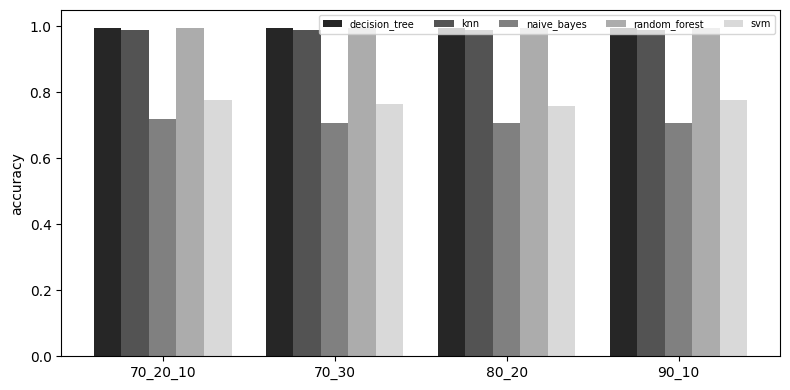

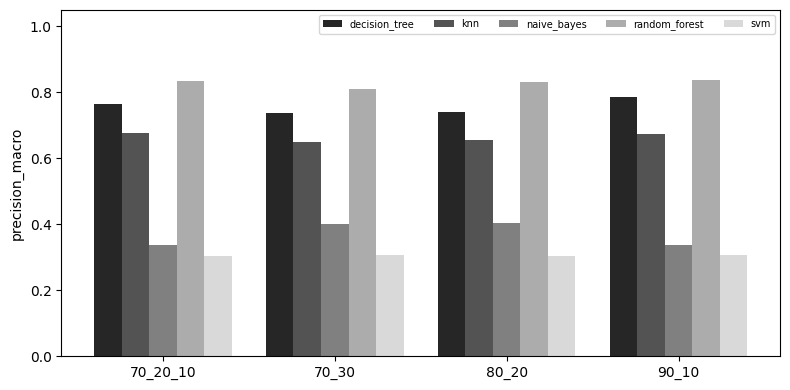

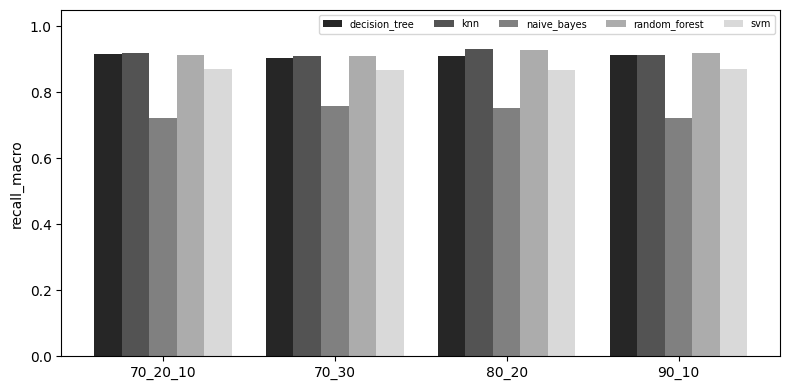

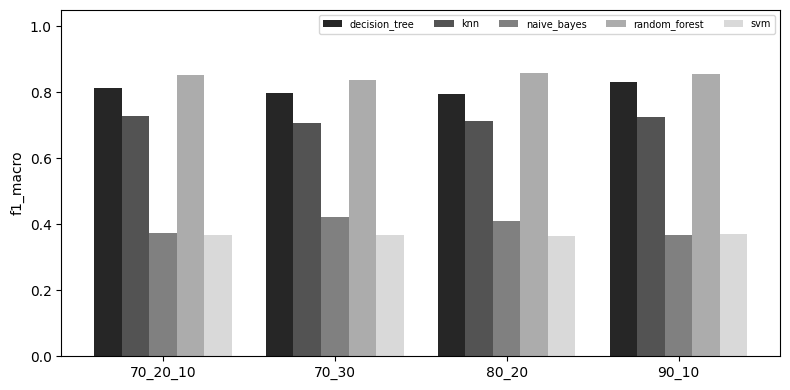

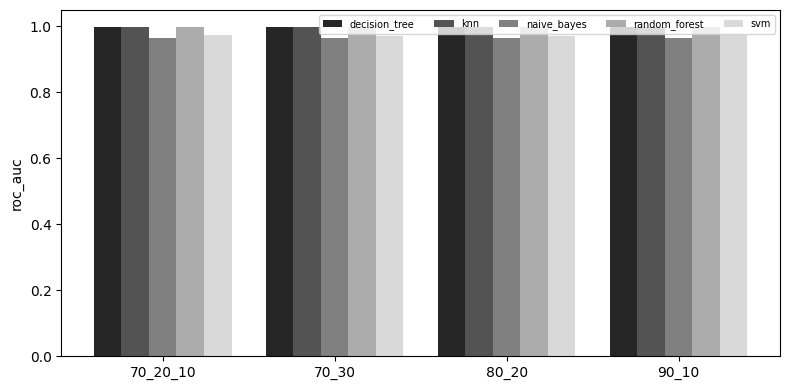

In [4]:
for metric in METRIC_NAMES:
    pv = pivots[metric]
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(pv.columns))
    width = 0.8 / len(pv.index)
    for i, model in enumerate(pv.index):
        ax.bar(x + i * width, pv.loc[model], width,
               label=model, color=str(0.15 + 0.7 * i / max(1, len(pv.index) - 1)))
    ax.set_xticks(x + 0.4 - width / 2)
    ax.set_xticklabels(pv.columns)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, ncol=len(pv.index))
    fig.tight_layout()
    fig.savefig(P.results / "plots" / f"{metric}_by_scheme.png", dpi=150)
    plt.show()

## 2. Cross-validation (cv5): mean ± std per model

In [5]:
cv_summary_path = P.runs / "cv5" / "cv_summary.csv"
if cv_summary_path.exists():
    cv_summary = pd.read_csv(cv_summary_path)
    cv_summary.to_csv(P.results / "cv5_summary.csv", index=False)
    display(cv_summary.round(4))
else:
    log.warning("no cv5 results found at %s", cv_summary_path)

,model,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,roc_auc_mean,roc_auc_std
0,decision_tree,0.9960,0.0002,0.7453,0.0136,0.9130,0.0310,0.7996,0.0117,0.9980,0.0001
1,knn,0.9889,0.0003,0.6639,0.0085,0.9059,0.0159,0.7164,0.0054,0.9977,0.0001
2,naive_bayes,0.7110,0.0037,0.4036,0.0008,0.7643,0.0217,0.4286,0.0098,0.9647,0.0010
3,random_forest,0.9958,0.0007,0.8325,0.0224,0.9024,0.0101,0.8470,0.0169,0.9998,0.0000
4,svm,0.7752,0.0044,0.3114,0.0091,0.8403,0.0059,0.3731,0.0109,0.9729,0.0009


## 3. Validation vs test on the 70/20/10 scheme

In [6]:
vt = summary[summary["scheme"] == "70_20_10"].pivot_table(
    index="model", columns="split",
    values=[m for m in METRIC_NAMES if m in summary.columns]).round(4)
vt.to_csv(P.results / "val_vs_test_70_20_10.csv")
vt

accuracy            f1_macro            precision_macro  \
split             test validation     test validation            test   
model                                                                   
decision_tree   0.9963     0.9962   0.8132     0.7895          0.7645   
knn             0.9890     0.9888   0.7288     0.7218          0.6775   
naive_bayes     0.7209     0.7207   0.3729     0.4370          0.3387   
random_forest   0.9957     0.9954   0.8544     0.8507          0.8350   
svm             0.7760     0.7754   0.3669     0.3664          0.3048   

                         recall_macro            roc_auc             
split         validation         test validation    test validation  
model                                                                
decision_tree     0.7304       0.9170     0.9098  0.9981     0.9981  
knn               0.6736       0.9186     0.8963  0.9979     0.9978  
naive_bayes       0.4036       0.7225     0.7553  0.9660     0.9658  
random_forest     0.8550       0.9129     0.8999  0.9998     0.9998  
svm               0.3041       0.8703     0.8474  0.9739     0.9735

## 4. Feature-set overlap with the base (RF-importance) study

In [7]:
mine = nbc.load_json(P.features / "top40.json")
base_path = config.ARTIFACTS_DIR / "ft40" / DATASET / "features" / "top40.json"
if base_path.exists():
    base = nbc.load_json(base_path)
    shared = sorted(set(mine["selected"]) & set(base["selected"]))
    only_mine = sorted(set(mine["selected"]) - set(base["selected"]))
    only_base = sorted(set(base["selected"]) - set(mine["selected"]))
    overlap = {"method": mine.get("method"), "n_shared_with_rf_importance": len(shared),
               "shared": shared, "only_this_method": only_mine, "only_rf_importance": only_base}
    nbc.save_json(overlap, P.results / "feature_overlap_vs_base.json")
    log.info("%d/40 features shared with the RF-importance study", len(shared))
    print(f"shared with base study: {len(shared)}/40")
else:
    log.warning("base study top40 not found at %s — overlap skipped", base_path)

2026-07-06 17:18:23,338 INFO nb05: 26/40 features shared with the RF-importance study
shared with base study: 26/40


## 5. Artifact inventory (what backs every number above)

In [8]:
inventory = sorted(str(p.relative_to(P.root)) for p in P.root.rglob("*") if p.is_file())
nbc.save_json(inventory, P.results / "artifact_inventory.json")
log.info("study produced %d artifact files under %s", len(inventory), P.root)
print(f"{len(inventory)} files; key results:")
for f in inventory:
    if f.startswith("results/") and f.endswith(".csv"):
        print(" ", f)

2026-07-06 17:18:23,396 INFO nb05: study produced 183 artifact files under /Users/MAC/Projects/IDS/backend/artifacts/ft40_rfe/cic2017
183 files; key results:
  results/cv5_summary.csv
  results/pivot_accuracy.csv
  results/pivot_detection_time_ms.csv
  results/pivot_f1_macro.csv
  results/pivot_fit_seconds.csv
  results/pivot_precision_macro.csv
  results/pivot_recall_macro.csv
  results/pivot_roc_auc.csv
  results/summary_all_schemes.csv
  results/val_vs_test_70_20_10.csv
